# 02 — Data preparation and locked split

**Research question:** To what extent does end-to-end representation learning improve multiclass steel-surface defect classification over handcrafted HOG features, and are any performance gains maintained under validation, image-condition variation and practical deployment constraints?

This notebook resolves the audited duplicate and creates the shared **80/20 stratified development/test split, seed 42**. It trains no models. All experimental logic is included here; no private modules or earlier notebook variables are needed. Run from the project root using **Restart Kernel and Run All**.

Install first (Windows, from the project root):
```bat
venv\Scripts\python.exe -m pip install numpy pandas matplotlib pillow scikit-learn ipykernel
```

The task is classification among six represented defect types. There is **no normal-steel class**. Existing `train/train/images` and `valid/valid/images` folders are treated as source containers, not our experimental partitions. Filename labels are used; annotation files are not classification inputs.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import re
import sys
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
TEST_SIZE = 0.20
EXPECTED_CLASSES = ['crazing', 'inclusion', 'patches', 'pitted_surface',
                    'rolled_in_scale', 'scratches']
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.pgm', '.webp'}
PROJECT_ROOT = Path.cwd().resolve()
DATASET_DIR = PROJECT_ROOT / 'data' / 'NEU-CLS'
METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
REPORTS_DIR = PROJECT_ROOT / 'outputs' / 'reports'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
for directory in [METRICS_DIR, REPORTS_DIR, FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
MANIFEST_PATH = METRICS_DIR / 'data_split_manifest.csv'
LOCK_PATH = METRICS_DIR / 'split_lock.json'
STATUS_PATH = REPORTS_DIR / '02_split_status.json'
CHECKS_PATH = REPORTS_DIR / '02_split_checks.csv'
STATUS_PATH.write_text(json.dumps({'status': 'IN_PROGRESS'}), encoding='utf-8')
checks = []

def require(name, passed, detail):
    checks.append({'check': name, 'status': 'PASS' if bool(passed) else 'FAIL',
                   'detail': str(detail)})
    pd.DataFrame(checks).to_csv(CHECKS_PATH, index=False)
    if not passed:
        STATUS_PATH.write_text(json.dumps({'status': 'FAIL', 'failed_check': name}), encoding='utf-8')
        raise RuntimeError(f'{name}: {detail}. Do not begin modelling.')

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open('rb') as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

def snapshot_raw():
    return {p.relative_to(DATASET_DIR).as_posix(): sha256_file(p)
            for p in sorted(DATASET_DIR.rglob('*')) if p.is_file()}

require('Dataset exists', DATASET_DIR.is_dir(), DATASET_DIR)
environment = {'python': platform.python_version(), 'executable': sys.executable,
               'packages': {p: version(p) for p in ['numpy', 'pandas', 'matplotlib', 'pillow', 'scikit-learn']}}
print(json.dumps(environment, indent=2))
raw_before = snapshot_raw()  # Covers annotations and dataset notes as well as images.

{
  "python": "3.14.0",
  "executable": "C:\\Scripts\\industrial-defect-intelligence\\venv\\Scripts\\python.exe",
  "packages": {
    "numpy": "2.5.3",
    "pandas": "3.0.6",
    "matplotlib": "3.11.2",
    "pillow": "12.3.0",
    "scikit-learn": "1.9.1"
  }
}


## 1. Labels from the actual filenames

The old notebook used `path.parent.name`, giving every image the label `images`. We now split the filename at its **last underscore**, preserving multiword labels such as `rolled-in_scale` and `pitted_surface`, then normalise hyphens to underscores. Only the six explicit expected labels and numeric image suffixes are accepted. Recognised class folders, if present, must agree. Unknown or conflicting evidence stops execution before any manifest is published.

In [2]:
def parse_label(path):
    stem = path.stem.lower()
    prefix, separator, number = stem.rpartition('_')
    label = prefix.replace('-', '_')
    if not separator or not re.fullmatch(r'[0-9]+', number) or label not in EXPECTED_CLASSES:
        raise ValueError(f'Unrecognised NEU-CLS filename: {path.name}')
    folder_labels = {part.lower().replace('-', '_') for part in path.parent.parts}
    conflicting = (folder_labels & set(EXPECTED_CLASSES)) - {label}
    if conflicting:
        raise ValueError(f'Folder/filename label conflict: {path}')
    return label

image_files = sorted((DATASET_DIR / rel for rel in raw_before
                      if Path(rel).suffix.lower() in IMAGE_EXTENSIONS),
                     key=lambda p: p.relative_to(PROJECT_ROOT).as_posix())
records, label_errors = [], []
for path in image_files:
    try:
        label = parse_label(path.relative_to(DATASET_DIR))
        records.append({'path': path.relative_to(PROJECT_ROOT).as_posix(),
                        'filename': path.name, 'class_name': label,
                        'label_source': 'filename_prefix', 'extension': path.suffix.lower(),
                        'sha256': raw_before[path.relative_to(DATASET_DIR).as_posix()]})
    except ValueError as exc:
        label_errors.append(str(exc))
require('Unambiguous filename labels', not label_errors, label_errors or 'All filenames recognised')
require('Raw image count', len(records) == 1800, f'{len(records)} images; expected 1800')
manifest = pd.DataFrame(records).sort_values('path').reset_index(drop=True)
require('Unique paths', manifest.path.is_unique, 'Every image appears once')
require('Expected six labels', set(manifest.class_name) == set(EXPECTED_CLASSES), sorted(manifest.class_name.unique()))
raw_counts = manifest.class_name.value_counts().reindex(EXPECTED_CLASSES, fill_value=0)
require('300 raw images per class', raw_counts.eq(300).all(), raw_counts.to_dict())
display(raw_counts.rename('raw_count').to_frame())

,raw_count
class_name,
crazing,300
inclusion,300
patches,300
pitted_surface,300
rolled_in_scale,300
scratches,300


## 2. Confirm integrity and resolve exact duplicates

Recheck readability, 200 × 200 dimensions and greyscale content instead of trusting stale audit outputs. Both byte SHA-256 and decoded RGB pixel SHA-256 are recorded. A duplicate with conflicting class labels stops execution. Retain the lexicographically first relative path in each exact-byte group; exclude the other copies **in the manifest only**. Any remaining identical decoded pixels stop execution for review. These checks do not establish the absence of near-duplicates or shared acquisition groups.

In [3]:
pixel_hashes, integrity_errors = [], []
for path in image_files:
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.load()
            if img.size != (200, 200) or getattr(img, 'n_frames', 1) != 1:
                raise ValueError(f'Unexpected dimensions/frames: {img.size}')
            rgb = np.asarray(img.convert('RGB'))
            if not (np.array_equal(rgb[..., 0], rgb[..., 1]) and np.array_equal(rgb[..., 1], rgb[..., 2])):
                raise ValueError('Pixel content is not greyscale')
            header = f'RGB:{img.width}:{img.height}:'.encode('ascii')
            pixel_hashes.append(hashlib.sha256(header + rgb.tobytes()).hexdigest())
    except Exception as exc:
        pixel_hashes.append(None)
        integrity_errors.append(f'{path.name}: {exc}')
require('Readable 200x200 single-frame greyscale images', not integrity_errors,
        integrity_errors or 'All 1800 images passed')
manifest['pixel_sha256'] = pixel_hashes
for key in ['sha256', 'pixel_sha256']:
    conflicts = manifest.groupby(key).class_name.nunique().gt(1)
    require(f'No conflicting labels for {key}', not conflicts.any(), f'{int(conflicts.sum())} conflicts')

counts = manifest.sha256.value_counts()
duplicate_hashes = sorted(counts[counts.gt(1)].index)
manifest['is_duplicate'] = manifest.sha256.isin(duplicate_hashes)
manifest['duplicate_group'] = manifest.sha256.map({h: i + 1 for i, h in enumerate(duplicate_hashes)}).astype('Int64')
manifest['canonical_path'] = manifest.groupby('sha256')['path'].transform('min')
manifest['include_in_modelling'] = manifest.path.eq(manifest.canonical_path)
manifest['exclusion_reason'] = np.where(manifest.include_in_modelling, '', 'redundant exact duplicate excluded')
modelling_manifest = manifest.loc[manifest.include_in_modelling].copy()
require('Audited exact duplicate group', len(duplicate_hashes) == 1 and
        set(manifest.loc[manifest.is_duplicate, 'filename']) == {'patches_101.jpg', 'patches_105.jpg'},
        manifest.loc[manifest.is_duplicate, 'filename'].tolist())
require('Unique modelling pool', len(modelling_manifest) == 1799 and modelling_manifest.sha256.is_unique,
        f'{len(modelling_manifest)} unique byte hashes')
require('No remaining pixel duplicates', modelling_manifest.pixel_sha256.is_unique,
        'Each retained image has distinct decoded pixels')
require('Exactly one exclusion', (~manifest.include_in_modelling).sum() == 1,
        manifest.loc[~manifest.include_in_modelling, 'filename'].tolist())
display(manifest.loc[manifest.is_duplicate, ['filename', 'class_name', 'canonical_path', 'include_in_modelling']])

,filename,class_name,canonical_path,include_in_modelling
592,patches_101.jpg,patches,data/NEU-CLS/train/train/images/patches_101.jpg,True
596,patches_105.jpg,patches,data/NEU-CLS/train/train/images/patches_101.jpg,False


## 3. Locked stratified 80/20 split

The 1,799 retained images produce **1,439 development and 360 test images**. Development data alone will support stratified five-fold cross-validation, preprocessing estimates, model selection and diagnostic threshold choices. The same partitions will be used for HOG–SVM and the compact CNN.

The first successful run publishes a manifest and a lock recording its checksum, source fingerprint, seed, policy and package version. Later runs **reuse the saved assignments** and check their integrity; they never silently replace an existing lock. A changed dataset or manifest requires explicit investigation. This is an integrity safeguard, not a security boundary or proof that a person has not looked at the test data.

In [4]:
dataset_fingerprint = hashlib.sha256(manifest[['path', 'class_name', 'sha256', 'pixel_sha256']]
                                    .to_csv(index=False, lineterminator='\n').encode('utf-8')).hexdigest()
policy = {'schema_version': 1, 'seed': RANDOM_SEED, 'test_size': TEST_SIZE,
          'classes': EXPECTED_CLASSES, 'dataset_fingerprint': dataset_fingerprint,
          'duplicate_policy': 'lexicographically first POSIX relative path per byte SHA-256'}
if LOCK_PATH.exists():
    lock = json.loads(LOCK_PATH.read_text(encoding='utf-8'))
    require('Lock policy and dataset match', all(lock.get(k) == v for k, v in policy.items()), policy)
    require('Locked manifest exists', MANIFEST_PATH.is_file(), MANIFEST_PATH)
    require('Manifest checksum matches lock', sha256_file(MANIFEST_PATH) == lock['manifest_sha256'],
            'Saved manifest must be unchanged')
    saved = pd.read_csv(MANIFEST_PATH, keep_default_na=False)
    require('Saved manifest paths match', saved.path.is_unique and set(saved.path) == set(manifest.path),
            'Exact path coverage required')
    final_manifest = manifest.copy()
    final_manifest['split'] = final_manifest.path.map(saved.set_index('path')['split'])
    print('Reusing verified locked split.')
else:
    require('No unverified existing manifest', not MANIFEST_PATH.exists(),
            'An existing manifest without a lock must be reviewed, not overwritten')
    development_indices, test_indices = train_test_split(
        modelling_manifest.index.to_numpy(), test_size=TEST_SIZE, random_state=RANDOM_SEED,
        stratify=modelling_manifest.class_name)
    final_manifest = manifest.copy()
    final_manifest['split'] = 'excluded'
    final_manifest.loc[development_indices, 'split'] = 'development'
    final_manifest.loc[test_indices, 'split'] = 'test'
    print('Prepared initial split; publication waits until checks pass.')

development_df = final_manifest.loc[final_manifest.split.eq('development')].copy()
test_df = final_manifest.loc[final_manifest.split.eq('test')].copy()
assigned = final_manifest.loc[final_manifest.split.isin(['development', 'test'])]
require('Only allowed split values', set(final_manifest.split) == {'development', 'test', 'excluded'},
        final_manifest.split.value_counts().to_dict())
require('Complete exclusive assignment', assigned.path.is_unique and
        set(assigned.path) == set(modelling_manifest.path), 'Every retained image assigned once')
require('Excluded images stay excluded', final_manifest.split.eq('excluded').equals(~final_manifest.include_in_modelling),
        'Exclusions exactly match duplicate policy')
require('80/20 partition sizes', len(development_df) == 1439 and len(test_df) == 360,
        f'Development={len(development_df)}; test={len(test_df)}')
for key in ['path', 'sha256', 'pixel_sha256']:
    overlap = set(development_df[key]) & set(test_df[key])
    require(f'No cross-partition overlap: {key}', not overlap, f'{len(overlap)} overlaps')
class_split_summary = pd.crosstab(final_manifest.class_name, final_manifest.split).reindex(
    index=EXPECTED_CLASSES, columns=['development', 'test', 'excluded'], fill_value=0)
require('Stratification in every class', class_split_summary.test.eq(60).all() and
        class_split_summary.development.eq(pd.Series({c: 239 if c == 'patches' else 240 for c in EXPECTED_CLASSES})).all(),
        class_split_summary.to_dict())
require('Raw dataset unchanged', snapshot_raw() == raw_before, f'{len(raw_before)} source files checked byte-for-byte')
manifest_bytes = final_manifest.to_csv(index=False, lineterminator='\n').encode('utf-8')
manifest_digest = hashlib.sha256(manifest_bytes).hexdigest()
if LOCK_PATH.exists():
    require('Reconstructed manifest matches saved lock', manifest_digest == lock['manifest_sha256'],
            'Labels, hashes, exclusions and assignments all agree')
display(class_split_summary)

Reusing verified locked split.


split,development,test,excluded
class_name,,,
crazing,240,60,0
inclusion,240,60,0
patches,239,60,1
pitted_surface,240,60,0
rolled_in_scale,240,60,0
scratches,240,60,0


## 4. Publish verified artefacts and validation evidence

All critical data checks precede publication. The lock is written last; downstream notebooks must require a matching PASS report and lock. A crash or failure leaves no valid success marker for that run. Existing manifests and locks are checked rather than overwritten. Generated summary tables and figures can be regenerated.

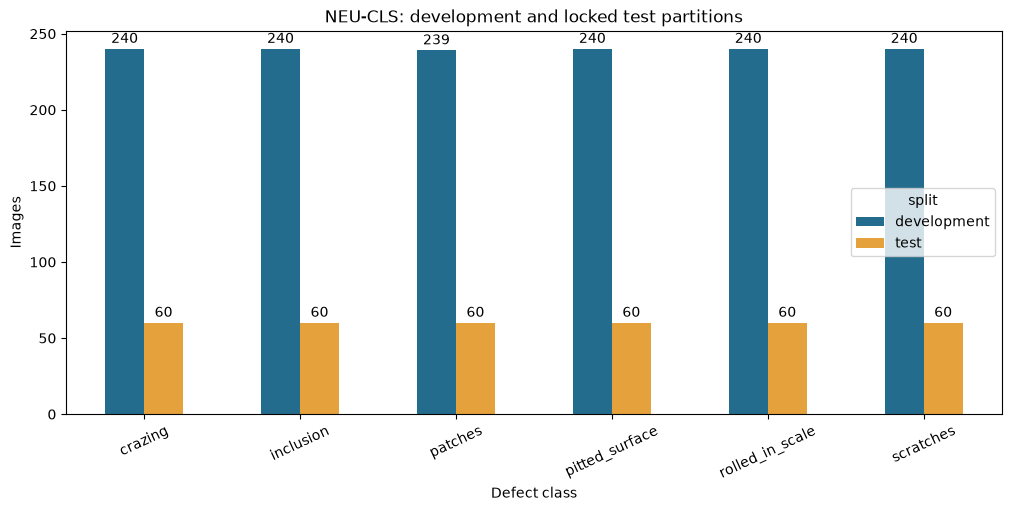

,check,status,detail
0,Dataset exists,PASS,C:\Scripts\industrial-defect-intelligence\data...
1,Unambiguous filename labels,PASS,All filenames recognised
2,Raw image count,PASS,1800 images; expected 1800
3,Unique paths,PASS,Every image appears once
4,Expected six labels,PASS,"['crazing', 'inclusion', 'patches', 'pitted_su..."
5,300 raw images per class,PASS,"{'crazing': 300, 'inclusion': 300, 'patches': ..."
6,Readable 200x200 single-frame greyscale images,PASS,All 1800 images passed
7,No conflicting labels for sha256,PASS,0 conflicts
8,No conflicting labels for pixel_sha256,PASS,0 conflicts
9,Audited exact duplicate group,PASS,"['patches_101.jpg', 'patches_105.jpg']"


OVERALL RESULT: PASS — critical split checks passed.
Development: 1439 | Locked test: 360 | Excluded duplicate: 1
No models trained. Use development data only for the next milestone.


In [5]:
if not LOCK_PATH.exists():
    temp = MANIFEST_PATH.with_suffix('.csv.tmp')
    temp.write_bytes(manifest_bytes)
    temp.replace(MANIFEST_PATH)
    lock = {**policy, 'manifest_sha256': manifest_digest, 'creation_environment': environment,
            'counts': {'raw': 1800, 'development': 1439, 'test': 360, 'excluded': 1},
            'test_use': 'Final comparison only, after both model configurations are frozen'}
    temp_lock = LOCK_PATH.with_suffix('.json.tmp')
    temp_lock.write_text(json.dumps(lock, indent=2) + '\n', encoding='utf-8')
    temp_lock.replace(LOCK_PATH)
require('Saved manifest verified', sha256_file(MANIFEST_PATH) == manifest_digest, manifest_digest)
class_split_summary.to_csv(METRICS_DIR / '02_split_class_counts.csv')
final_manifest.loc[final_manifest.is_duplicate].to_csv(REPORTS_DIR / '02_duplicate_decisions.csv', index=False)
(REPORTS_DIR / '02_environment.json').write_text(json.dumps(environment, indent=2), encoding='utf-8')

fig, ax = plt.subplots(figsize=(10, 5), layout='constrained')
class_split_summary[['development', 'test']].plot.bar(ax=ax, color=['#246c8e', '#e5a23c'])
ax.set(title='NEU-CLS: development and locked test partitions', xlabel='Defect class', ylabel='Images')
ax.tick_params(axis='x', rotation=25)
for container in ax.containers:
    ax.bar_label(container, padding=2)
fig.savefig(FIGURES_DIR / '02_split_class_distribution.png', dpi=160)
plt.show()
plt.close(fig)

require('Raw dataset still unchanged after publication', snapshot_raw() == raw_before,
        f'All {len(raw_before)} source files preserved')
STATUS_PATH.write_text(json.dumps({'status': 'PASS', 'manifest_sha256': manifest_digest,
    'dataset_fingerprint': dataset_fingerprint, 'critical_checks_passed': len(checks),
    'warnings': ['Local archive-to-Figshare provenance remains unverified',
                 'Full-collection EDA preceded the test split',
                 'Near-duplicate and acquisition-group independence not established']}, indent=2), encoding='utf-8')
display(pd.DataFrame(checks))
print('OVERALL RESULT: PASS — critical split checks passed.')
print('Development: 1439 | Locked test: 360 | Excluded duplicate: 1')
print('No models trained. Use development data only for the next milestone.')

## 5. Methodological record and next milestone

- **Observed → risk → decision:** generic image folders produced one spurious class; explicit filename parsing and exact class validation now fail early. The former invalid notebook, manifest and figure are retained under `outputs/reports/before_label_fix/` as historical evidence, not experimental inputs.
- The audit found `patches_101.jpg` and `patches_105.jpg` identical. The first is retained and the second excluded, leaving patches with 299 usable examples. No raw image is deleted or edited.
- Images are stored as RGB but contain greyscale pixels. Modelling will explicitly convert to one channel in memory.
- Full-collection EDA was already performed before reserving the test set. Disclose this limitation: it is not a prospectively untouched external sample. Future learned preprocessing, subgroup thresholds, augmentation choices and tuning must use development data only.
- Exact hashes do not detect near-duplicates. Acquisition group identifiers are unavailable, so this is an image-level split and does not establish cross-factory generalisation.
- The earlier conversation identifies the Figshare distribution and original Northeastern University provenance. Matching the local copy to an unchanged source archive remains unverified; a local fingerprint alone cannot prove origin. Do not mark provenance as verified.

Next: prepare common stratified five-fold development assignments, then HOG–SVM, then the compact CNN. Report accuracy and macro precision/recall/F1, per-class results, fold variability, XAI, natural image-condition diagnostics, synthetic robustness and efficiency. Fit scalers within training folds; keep validation/test images out of augmentation and fitting. HOG visualisation describes features, not an SVM decision explanation.

The eventual submission notebook must include all core logic and recreate outputs from an otherwise empty folder using the user's direct dataset URL and a verified archive checksum. That URL/checksum are still pending. These development notebooks are not a completed submission.